# データセットの作成

In [1]:
import sys
from pathlib import Path
# projectルートを追加
sys.path.append(str(Path().resolve().parent))

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

print("numpy:",np.__version__)
print("pandas:",pd.__version__)
print("matplotlib:",matplotlib.__version__)

numpy: 2.4.2
pandas: 3.0.1
matplotlib: 3.10.8


In [2]:
from pathlib import Path
import pandas as pd

base_path = Path("../data/raw")

dfs = []

for year in range(2016, 2023):  # 2022まで
    csv_path = base_path / f"spot_summary_{year}.csv"
    df_year = pd.read_csv(csv_path, encoding="cp932")
    dfs.append(df_year)

# 結合
df = pd.concat(dfs, ignore_index=True)

# 日付をdatetime化
df["受渡日"] = pd.to_datetime(df["受渡日"])

# 時刻コード → 30分刻み
df["datetime"] = (
    df["受渡日"]
    + pd.to_timedelta((df["時刻コード"] - 1) * 30, unit="min")
)

# indexに設定
df = df.set_index("datetime").sort_index()

df.head()

,受渡日,時刻コード,売り入札量(kWh),買い入札量(kWh),約定総量(kWh),システムプライス(円/kWh),エリアプライス北海道(円/kWh),エリアプライス東北(円/kWh),エリアプライス東京(円/kWh),エリアプライス中部(円/kWh),エリアプライス北陸(円/kWh),エリアプライス関西(円/kWh),エリアプライス中国(円/kWh),エリアプライス四国(円/kWh),エリアプライス九州(円/kWh),売りブロック入札総量(kWh),売りブロック約定総量(kWh),買いブロック入札総量(kWh),買いブロック約定総量(kWh)
datetime,,,,,,,,,,,,,,,,,,,
2016-04-01 00:00:00,2016-04-01,1,5077000,2120500,675500,6.61,8.66,6.69,6.69,6.69,6.69,6.69,6.69,6.69,4.00,1665000,45000,NaN,NaN
2016-04-01 00:30:00,2016-04-01,2,5621500,2239000,755500,6.34,8.66,6.34,6.34,6.34,6.34,6.34,6.34,6.34,4.00,1979000,195000,NaN,NaN
2016-04-01 01:00:00,2016-04-01,3,5710500,2219000,713500,6.34,7.20,6.34,6.34,6.34,6.34,6.34,6.34,6.34,4.00,2236500,195000,NaN,NaN
2016-04-01 01:30:00,2016-04-01,4,5536000,2202500,717500,6.25,7.10,6.03,6.03,6.03,6.03,6.03,6.03,6.03,4.00,2236500,195000,NaN,NaN
2016-04-01 02:00:00,2016-04-01,5,5461000,2192000,870500,6.57,7.10,6.57,6.57,6.57,6.57,6.57,6.57,6.57,5.28,2191500,170000,NaN,NaN


In [3]:
from pathlib import Path
import numpy as np
import pandas as pd

# =========================================================
# 0. エリア列定義
# =========================================================
AREA_COLS = {
    "Hokkaido": "エリアプライス北海道(円/kWh)",
    "Tohoku":   "エリアプライス東北(円/kWh)",
    "Tokyo":    "エリアプライス東京(円/kWh)",
    "Chubu":    "エリアプライス中部(円/kWh)",
    "Hokuriku": "エリアプライス北陸(円/kWh)",
    "Kansai":   "エリアプライス関西(円/kWh)",
    "Chugoku":  "エリアプライス中国(円/kWh)",
    "Shikoku":  "エリアプライス四国(円/kWh)",
    "Kyushu":   "エリアプライス九州(円/kWh)",
}

# =========================================================
# 1. 営業日/非営業日フラグ作成
#    デフォルトは「土日=非営業日」。
#    jpholiday が入っていれば日本の祝日も非営業日にする。
# =========================================================
def add_day_type_flags(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    # date列（正規化）
    out["date"] = pd.to_datetime(out["受渡日"]).dt.normalize()

    # weekday: Mon=0, ..., Sun=6
    out["weekday"] = out["date"].dt.weekday

    # デフォルトは土日を非営業日
    is_holiday = pd.Series(False, index=out.index)

    try:
        import jpholiday
        is_holiday = out["date"].map(lambda d: jpholiday.is_holiday(d))
    except Exception:
        pass

    out["is_nonworkday"] = (out["weekday"] >= 5) | is_holiday
    out["is_workday"] = ~out["is_nonworkday"]

    return out


# =========================================================
# 2. 論文の考え方に沿ったスケーリング係数を作る
#
# k_d^{a,t} = (その日までの平日平均) / (その日までの休日平均)
#
# 非営業日の価格だけを:
#   scaled_price = k * original_price
# 平日はそのまま
#
# 係数が計算できない初期時点では 1.0 を使う
# =========================================================
def scale_area_prices_by_daytype(
    df: pd.DataFrame,
    area_cols: dict = AREA_COLS,
    min_periods: int = 1
) -> pd.DataFrame:
    out = add_day_type_flags(df)

    # 念のため時刻コードが数値であることを保証
    out["時刻コード"] = out["時刻コード"].astype(int)

    for area_name, col in area_cols.items():
        # 平日価格 / 休日価格を分ける
        work_price = out[col].where(out["is_workday"])
        nonwork_price = out[col].where(out["is_nonworkday"])

        # 日付×時刻コードごとに expanding mean を作るため groupby
        grp_keys = out["時刻コード"]

        # その時刻コードにおける「当日までの平日平均」
        work_mean_to_date = (
            work_price.groupby(grp_keys)
            .transform(lambda s: s.expanding(min_periods=min_periods).mean())
        )

        # その時刻コードにおける「当日までの休日平均」
        nonwork_mean_to_date = (
            nonwork_price.groupby(grp_keys)
            .transform(lambda s: s.expanding(min_periods=min_periods).mean())
        )

        # 係数 k = work / nonwork
        k = work_mean_to_date / nonwork_mean_to_date

        # 初期に NaN や inf が出るので補正
        k = k.replace([np.inf, -np.inf], np.nan).fillna(1.0)

        # 休日だけスケーリング
        scaled_col = f"{col}_scaled"
        out[scaled_col] = np.where(
            out["is_nonworkday"],
            out[col] * k,
            out[col]
        )

        # 係数自体も保存しておくと検証に便利
        out[f"{col}_scale_factor"] = k

    return out


# =========================================================
# 3. df_scaled を作る
#
# 元の df の構造をなるべく保ちつつ、
# エリア価格列を scaled 版で置き換えた DataFrame を返す
# =========================================================
def make_df_scaled(
    df: pd.DataFrame,
    area_cols: dict = AREA_COLS
) -> pd.DataFrame:
    tmp = scale_area_prices_by_daytype(df, area_cols=area_cols)

    out = tmp.copy()

    # 元の価格列を scaled 版に置換
    for _, col in area_cols.items():
        scaled_col = f"{col}_scaled"
        out[col] = out[scaled_col]

    # 補助列を残したい場合はこのままでもよいが、
    # 論文再現用にシンプル化したいなら scaled補助列を落とす
    drop_cols = []
    for _, col in area_cols.items():
        drop_cols.extend([f"{col}_scaled", f"{col}_scale_factor"])

    out = out.drop(columns=drop_cols, errors="ignore")

    return out


# =========================================================
# 4. spike_long を作る
#
# 出力列:
#   date, area, time_code, price, u, x
#
# x = max(price - threshold, 0)
# u = 1(price > threshold)
# =========================================================
def make_spike_long(
    df_scaled: pd.DataFrame,
    threshold: float = 25.0,
    area_cols: dict = AREA_COLS
) -> pd.DataFrame:
    records = []

    for area_name, col in area_cols.items():
        tmp = df_scaled[[col, "受渡日", "時刻コード"]].copy()
        tmp = tmp.rename(columns={
            col: "price",
            "受渡日": "date",
            "時刻コード": "time_code"
        })

        tmp["date"] = pd.to_datetime(tmp["date"]).dt.normalize()
        tmp["area"] = area_name
        tmp["u"] = (tmp["price"] > threshold).astype(int)
        tmp["x"] = (tmp["price"] - threshold).clip(lower=0.0)

        records.append(tmp[["date", "area", "time_code", "price", "u", "x"]])

    spike_long = pd.concat(records, ignore_index=True)
    spike_long = spike_long.sort_values(["area", "date", "time_code"]).reset_index(drop=True)

    return spike_long


# =========================================================
# 5. u_dict[area] を作る
#
# 形式:
#   index   = date
#   columns = time_code (1..48)
#   values  = u
# =========================================================
def make_u_dict(spike_long: pd.DataFrame) -> dict:
    u_dict = {}

    for area in spike_long["area"].unique():
        tmp = spike_long.loc[spike_long["area"] == area, ["date", "time_code", "u"]].copy()

        u_wide = (
            tmp.pivot(index="date", columns="time_code", values="u")
            .sort_index()
            .sort_index(axis=1)
        )

        # 全日・全時刻コードを埋める（欠損があれば0で埋める）
        full_cols = list(range(1, 49))
        u_wide = u_wide.reindex(columns=full_cols)
        u_wide = u_wide.fillna(0).astype(int)

        u_dict[area] = u_wide

    return u_dict


# =========================================================
# 6. ついでに x_dict も作ると便利
# =========================================================
def make_x_dict(spike_long: pd.DataFrame) -> dict:
    x_dict = {}

    for area in spike_long["area"].unique():
        tmp = spike_long.loc[spike_long["area"] == area, ["date", "time_code", "x"]].copy()

        x_wide = (
            tmp.pivot(index="date", columns="time_code", values="x")
            .sort_index()
            .sort_index(axis=1)
        )

        full_cols = list(range(1, 49))
        x_wide = x_wide.reindex(columns=full_cols)
        x_wide = x_wide.fillna(0.0)

        x_dict[area] = x_wide

    return x_dict


# =========================================================
# 7. 全部まとめて作るラッパー
# =========================================================
def build_spike_datasets(
    df: pd.DataFrame,
    threshold: float = 25.0,
    area_cols: dict = AREA_COLS
):
    df_scaled = make_df_scaled(df, area_cols=area_cols)
    spike_long = make_spike_long(df_scaled, threshold=threshold, area_cols=area_cols)
    u_dict = make_u_dict(spike_long)
    x_dict = make_x_dict(spike_long)

    return df_scaled, spike_long, u_dict, x_dict

In [4]:
df_scaled, spike_long, u_dict, x_dict = build_spike_datasets(
    df,
    threshold=25.0
)

df_scaled.head()

,受渡日,時刻コード,売り入札量(kWh),買い入札量(kWh),約定総量(kWh),システムプライス(円/kWh),エリアプライス北海道(円/kWh),エリアプライス東北(円/kWh),エリアプライス東京(円/kWh),エリアプライス中部(円/kWh),...,エリアプライス四国(円/kWh),エリアプライス九州(円/kWh),売りブロック入札総量(kWh),売りブロック約定総量(kWh),買いブロック入札総量(kWh),買いブロック約定総量(kWh),date,weekday,is_nonworkday,is_workday
datetime,,,,,,,,,,,,,,,,,,,,,
2016-04-01 00:00:00,2016-04-01,1,5077000,2120500,675500,6.61,8.66,6.69,6.69,6.69,...,6.69,4.00,1665000,45000,NaN,NaN,2016-04-01,4,False,True
2016-04-01 00:30:00,2016-04-01,2,5621500,2239000,755500,6.34,8.66,6.34,6.34,6.34,...,6.34,4.00,1979000,195000,NaN,NaN,2016-04-01,4,False,True
2016-04-01 01:00:00,2016-04-01,3,5710500,2219000,713500,6.34,7.20,6.34,6.34,6.34,...,6.34,4.00,2236500,195000,NaN,NaN,2016-04-01,4,False,True
2016-04-01 01:30:00,2016-04-01,4,5536000,2202500,717500,6.25,7.10,6.03,6.03,6.03,...,6.03,4.00,2236500,195000,NaN,NaN,2016-04-01,4,False,True
2016-04-01 02:00:00,2016-04-01,5,5461000,2192000,870500,6.57,7.10,6.57,6.57,6.57,...,6.57,5.28,2191500,170000,NaN,NaN,2016-04-01,4,False,True


In [5]:
import pandas as pd

# エリアプライス列だけ抽出
area_cols = [col for col in df.columns if "エリアプライス" in col]

# 統計量計算
stats = pd.DataFrame({
    "mean": df_scaled[area_cols].mean(),
    "median": df_scaled[area_cols].median(),
    "std": df_scaled[area_cols].std(),
    "skew": df_scaled[area_cols].skew(),
    "95": df_scaled[area_cols].quantile(0.95) # 歪度　スパイクが起きているのでsknw>0になる可能性が
})

stats

,mean,median,std,skew,95
エリアプライス北海道(円/kWh),14.644186,11.630000,12.879640,6.875271,32.090000
エリアプライス東北(円/kWh),13.057772,9.693571,13.013724,7.148145,30.740000
エリアプライス東京(円/kWh),13.458925,9.856848,13.311518,6.985009,32.085633
エリアプライス中部(円/kWh),12.124541,8.730000,11.976370,6.776184,29.348526
エリアプライス北陸(円/kWh),11.917622,8.712717,11.686229,7.174125,28.160000
エリアプライス関西(円/kWh),11.900129,8.710000,11.671492,7.198626,28.040000
エリアプライス中国(円/kWh),11.842348,8.700000,11.604883,7.298983,27.695740
エリアプライス四国(円/kWh),11.820267,8.700000,11.602175,7.365682,27.475490
エリアプライス九州(円/kWh),10.483391,8.117488,11.098578,8.394700,24.291246


In [6]:
spike_long.head()

,date,area,time_code,price,u,x
0,2016-04-01,Chubu,1,6.69,0,0.0
1,2016-04-01,Chubu,2,6.34,0,0.0
2,2016-04-01,Chubu,3,6.34,0,0.0
3,2016-04-01,Chubu,4,6.03,0,0.0
4,2016-04-01,Chubu,5,6.57,0,0.0


In [7]:
u_dict["Tokyo"].head()

time_code,1,2,3,4,5,6,7,8,9,10,...,39,40,41,42,43,44,45,46,47,48
date,,,,,,,,,,,,,,,,,,,,,
2016-04-01,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2016-04-02,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2016-04-03,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2016-04-04,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2016-04-05,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


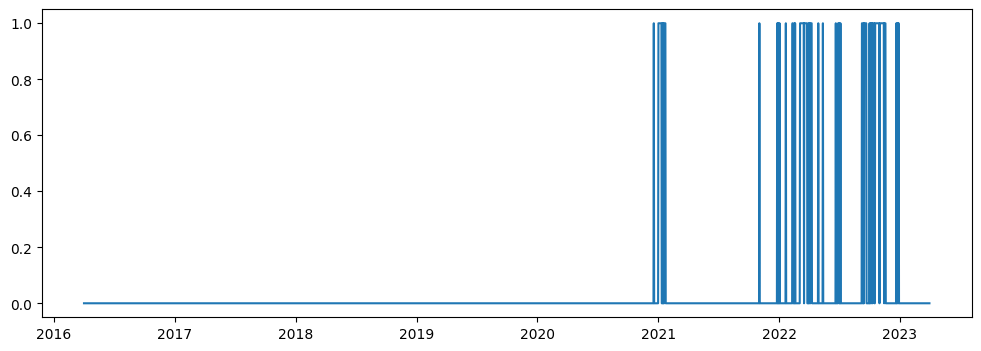

In [8]:
plt.figure(figsize=(12,4))
plt.plot(u_dict["Tokyo"][10])
plt.show()

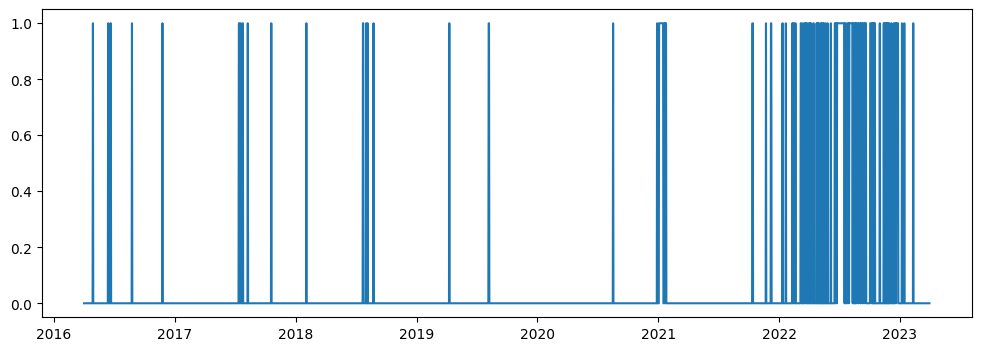

In [9]:
plt.figure(figsize=(12,4))
plt.plot(u_dict["Tokyo"][24])
plt.show()

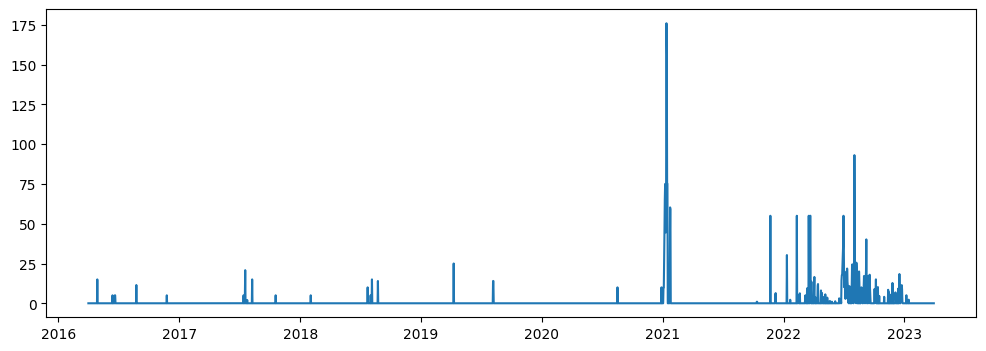

In [10]:
plt.figure(figsize=(12,4))
plt.plot(x_dict["Tokyo"][24])
plt.show()

In [11]:
# indexを列に戻す
spike_long_reset = spike_long.reset_index()

# 保存
spike_long_reset.to_csv("../data/processed/spike_long.csv", index=False, encoding="utf-8")

print("spike_long.csv saved")

spike_long.csv saved


In [12]:
from pathlib import Path

output_dir = Path("../data/processed/u_dict")
output_dir.mkdir(parents=True, exist_ok=True)

for area, df_area in u_dict.items():
    file_path = output_dir / f"u_{area}.csv"
    df_area.to_csv(file_path, encoding="utf-8")

print("u_dict CSVs saved")

u_dict CSVs saved


In [13]:
output_dir = Path("../data/processed/x_dict")
output_dir.mkdir(parents=True, exist_ok=True)

for area, df_area in x_dict.items():
    file_path = output_dir / f"x_{area}.csv"
    df_area.to_csv(file_path, encoding="utf-8")

print("x_dict CSVs saved")

x_dict CSVs saved
